In [1]:
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as  sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

c:\Users\TOLU\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\TOLU\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Mar  5 19:06:55 2026).


In [2]:
df_US = df[df['job_country']== 'United States'].dropna(subset='salary_year_avg')

In [3]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

In [4]:
df_US_top6=df_US[df_US['job_title_short'].isin (job_titles)]

In [5]:
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index


<function matplotlib.pyplot.show(close=None, block=None)>

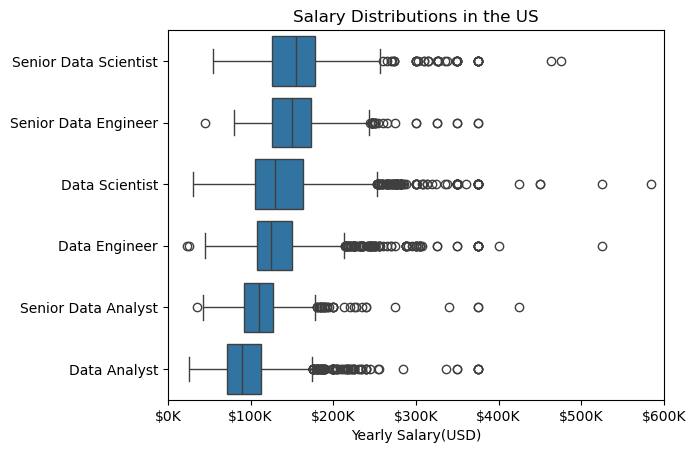

In [6]:
sns.boxplot(data=df_US_top6, x= 'salary_year_avg', y= 'job_title_short',order=job_order)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.title('Salary Distributions in the US')
plt.ylabel('')
plt.xlabel('Yearly Salary(USD)')
plt.xlim(0, 600000)
plt.show

In [ ]:
df_DA_US=df[(df['job_country']== 'United States') & (df['job_title_short']== 'Data Analyst')].copy()

df_DA_US=df_DA_US.dropna(subset='salary_year_avg')

In [12]:
df_DA_US= df_DA_US.explode('job_skills')

df_DA_US[['job_title_short','job_skills']].head(5)

,job_title_short,job_skills
109,Data Analyst,python
109,Data Analyst,r
109,Data Analyst,alteryx
109,Data Analyst,tableau
180,Data Analyst,excel


In [23]:
df_DA_top_pay=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by= 'median', ascending=False)



In [21]:
df_DA_skills=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by= 'count', ascending=False)


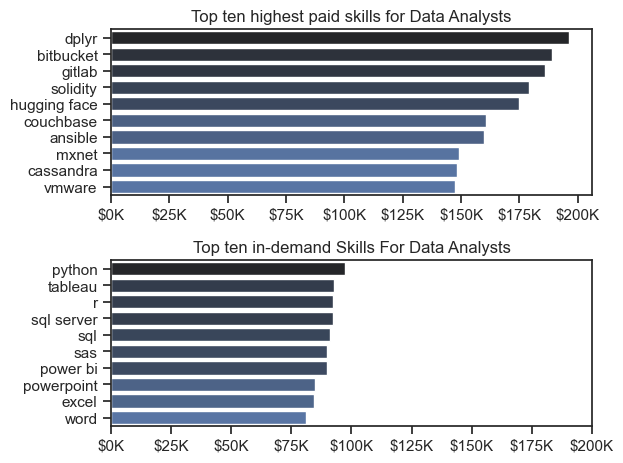

In [28]:
df_DA_US=df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US.groupby('job_skills', )['salary_year_avg'].agg(count='count', median= 'median')

df_DA_US_top_pay = df_DA_US_group.sort_values('median',ascending=False).head(10)
df_DA_US_skills = df_DA_US_group.sort_values('count', ascending=False).head(10).sort_values('median',ascending= False)
ig, ax = plt.subplots(2, 1)

sns.set_theme(style='ticks')
#df_DA_US_top_pay[::-1].plot(kind='barh', y= 'median',ax=ax[0],legend =False)
#df_DA_US_skills[::-1].plot(kind='barh',y='median', ax=ax[1],legend =False)
sns.barplot(data=df_DA_US_top_pay, x= 'median', y= df_DA_US_top_pay.index,ax=ax[0],hue='median',palette= 'dark:b_r',legend=False)
ax[0].set_title('Top ten highest paid skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
sns.barplot(data=df_DA_US_skills, x= 'median', y= df_DA_US_skills.index,ax=ax[1],hue='median',palette= 'dark:b_r',legend=False)
ax[1].set_title('Top ten in-demand Skills For Data Analysts')
ax[1].set_xlabel('')
ax[1].set_ylabel('')

ax[1].set_xlim(0, 200000)
for a in ax:
    a.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
#ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.tight_layout()
plt.show()